## **Algorithm : Non-linear SVM**

### **Project : Handwritten Digit Recognition**

#### **Kernel : RBF**

In [2]:
# Step No 1 : Import Required Libraries 
# Import numberical library 
import numpy as np 

# Import pandas library 
import pandas as pd 

# Import Plotting library 
import matplotlib.pyplot as plt

# Import seaborn library 
import seaborn as sns

# Import operating system library 
import os 

# Import image processing library 
from PIL import Image

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Standard Scaler 
from sklearn.preprocessing import StandardScaler

# Import Support Vector Classifier 
from sklearn.svm import SVC

# Import Evaluation Metrics 
from sklearn.metrics import(accuracy_score , classification_report , confusion_matrix)

In [3]:
# Step No 2 : Define Dataset Path 
# Path of extracted dataset folder 
dataset_path = "Handwritten_Digit_Image_Dataset_Visible"

In [4]:
# Step No 3 : Create Empty Lists 

# Store image pixel values 
X = []

# Store digit labels
y = []

In [5]:
# Step No 4 : Load Images From Dataset 
# Loop through digit folders 0 to 9 
for digit in range(10):
    
    # Create path for each digit folder 
    digit_folder = os.path.join(
        dataset_path,
        str(digit)
    )
    
    # Check whether folder exists 
    if not os.path.exists(digit_folder):
        print(
            f"Folder not found : {digit_folder}"
        )
        continue
    
    # Read all files from digit folder 
    for filename in os.listdir(digit_folder):
        
        # Create complete image path 
        image_path = os.path.join(
            digit_folder,
            filename
        )
        
        # Check image extension
        if filename.lower().endswith(
            (".png" , ".jpg" , ".jpeg")
        ):
            # Open Image 
            image = Image.open(
                image_path
            )
            
            # Convert image to grayscale 
            image = image.convert("L")
            
            # Resize image to 64 x 64 
            image = image.resize(
                (64 , 64)
            )
            
            # Convert image into Numpy array
            image_array = np.array(
                image
            )
            
            # Flatten 64 x 64 image 
            # into 1-dimensional vector 
            image_array = image_array.flatten()
            
            # Add image to X 
            X.append(
                image_array
            )
            
            # Add corresponding digit label 
            y.append(digit)

In [6]:
# Step No 5 : Convert Data Into Numpy Arrays 

# Convert image data into Numpy array 

X = np.array(X)

# Convert labels into Numpy array 
y = np.array(y)

In [7]:
# Step No 6 : Display Dataset Information

# Display Number of images 
print("\nNumber of Images : ")
print(len(X))

# Display feature shape 
print("\nFeature Shape : ")
print(X.shape)

# Display target shape 
print("\nTarget Shape : ")
print(y.shape)

# Display class distribution 
print("\nDigit Distribution : ")
print(pd.Series(y).value_counts().sort_index())


Number of Images : 
1797

Feature Shape : 
(1797, 4096)

Target Shape : 
(1797,)

Digit Distribution : 
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


In [8]:
# Step No 7 : Normalize Pixel Values 

# Convert pixel values from 0 - 255
# into 0-1 range 
X = X / 255.0


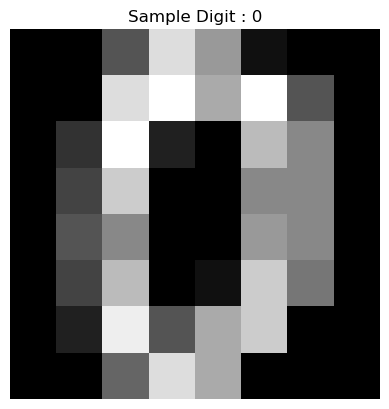

In [9]:
# Step No 8 :  Display Sample Image 
# Display first image 
plt.imshow(
    X[0].reshape(64 , 64),
    cmap= "grey"
)

# Set Title 
plt.title(
    f"Sample Digit : {y[0]}"
)
# Remove axis 
plt.axis("off")

# Display image
plt.show()

In [10]:
# Step No 9 : Train Test Split 
# Split dataset into training and testing data 
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [11]:
# Step No 10 : Feature Scaling 
scaler = StandardScaler()

# Fit scaler on training data 
# and transform training data 
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform testing data 
# using scaler learned from training data
X_test_scaled = scaler.transform(
    X_test 
)

In [12]:
# Step No 11 : Create Non-linear SVM Model 

# Create SVM model using RBF kernel 
model = SVC(
    kernel="rbf",
    C = 10 , 
    gamma = "scale"
)

# Display model 
print("\nNon-linear SVM Model : ")
print(model)


Non-linear SVM Model : 
SVC(C=10)


In [13]:
# Step No 12 : Train Model 

# Train Non-linear SVM Model 
model.fit(
    X_train_scaled,
    y_train
)
# Display training completion 
print(
    "\nNon-linear SVM Model Training Completed."
)


Non-linear SVM Model Training Completed.


In [14]:
# Step No 13 : Prediction 

# Predict digits from test data 
y_pred = model.predict(
    X_test_scaled
)

# Display Predications 
print("\nPredicted Values : ")
print(y_pred)


Predicted Values : 
[5 2 8 1 7 2 6 2 6 5 0 5 9 3 4 4 2 4 9 9 6 3 8 1 2 5 6 0 3 4 6 7 2 6 6 6 6
 5 0 9 1 7 9 6 5 7 5 2 7 5 0 1 5 5 3 2 4 0 0 2 7 5 6 1 3 7 6 5 7 0 9 0 3 8
 2 5 8 2 3 5 9 3 2 7 9 6 8 1 0 1 2 9 4 7 1 2 7 8 4 2 6 9 3 7 3 9 6 1 1 0 9
 2 1 6 3 7 8 7 1 0 0 4 6 5 8 2 8 8 3 0 0 8 6 4 3 6 3 3 3 3 0 5 0 0 1 9 5 8
 1 5 0 6 6 6 6 1 7 7 6 7 7 8 7 3 6 5 9 0 3 8 0 9 8 1 9 5 9 5 8 9 9 7 9 1 9
 5 4 7 3 0 4 9 7 7 5 6 5 8 3 4 5 4 9 2 5 5 2 1 3 8 8 9 3 6 1 0 1 4 0 5 5 6
 6 7 4 3 8 4 4 0 7 9 2 8 4 8 4 2 4 0 0 0 2 6 7 0 4 5 2 2 9 0 4 6 4 2 3 9 2
 3 0 6 8 7 1 4 4 1 1 6 3 8 1 2 5 7 8 3 2 0 3 4 1 9 9 9 6 3 7 1 6 9 4 7 1 8
 1 3 0 5 3 4 1 9 3 5 4 7 4 1 5 1 5 0 9 8 4 2 3 8 4 1 2 0 1 1 4 4 5 7 5 0 3
 2 2 4 2 7 7 8 7 6 3 1 1 5 8 8 8 6 7 2 7 8 9 4 2 0 3 4]


In [15]:
# Step No 14 : Evaluation Metrics 

# Calculate accuracy 
accuracy = accuracy_score(
    y_test , 
    y_pred
)

# Display accuracy 
print("\nAccuracy Score : ")
print(accuracy)

# Display accuracy percentage 
print("\nAccuracy Percentage : ")
print(
    round(
        accuracy * 100 , 
        2
    ),
    "%"
)

# Calculate Classification Report 
# Display precision , recall and F1 - score 
print("\nClassification Report : ")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# Confusion Matrix 
cm = confusion_matrix(
    y_test , 
    y_pred
)

# Display confusion matrix 
print("\nConfusion Matrix : ")
print(cm)


Accuracy Score : 
0.9805555555555555

Accuracy Percentage : 
98.06 %

Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       1.00      0.94      0.97        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360


Confusion Matrix : 
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  0  0  1  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0

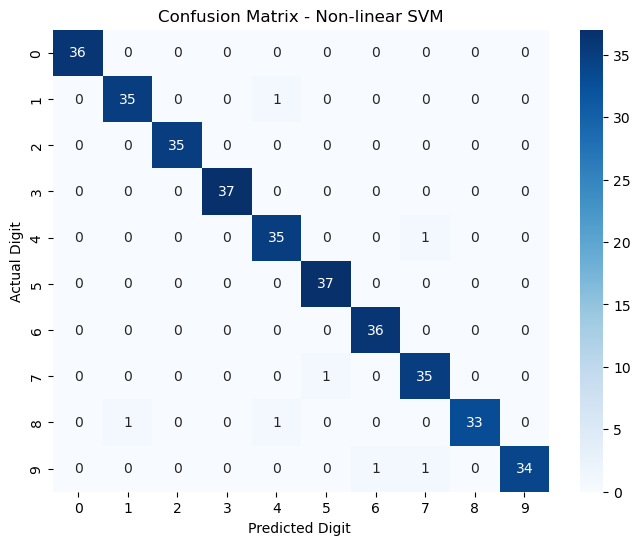

In [16]:
# Step No 15 : Confusion Matrix Visualization 

# Create Heatmap 
plt.figure(figsize=(8 , 6))
sns.heatmap(
    cm , 
    annot=True , 
    fmt = "d",
    cmap = "Blues"
)

# Set Title 
plt.title(
    "Confusion Matrix - Non-linear SVM"
)
# Set x-axis label 
plt.xlabel("Predicted Digit ")

# Set y-axis label 
plt.ylabel("Actual Digit")

# Display Plot 
plt.show()

In [17]:
# Step No 16 : Final Model Perforamance 

print("\n=============================")
print("       NON-LINEAR SVM PERFORMANCE")
print("===============================")

print(
    "Accuracy : ",
    round(
        accuracy * 100 , 
        2
    ),
    "%"
)

print("=============================")


       NON-LINEAR SVM PERFORMANCE
Accuracy :  98.06 %


In [18]:
# Step No : 17 : User Image Predication 

# Ask user for image path 
user_image_path = input(
    "\nEnter Handwritten Digit Image Path : "
)

# Check whether image exists 
if os.path.exists(user_image_path):
    
    # Open user image 
    user_image = Image.open(
        user_image_path
    )
    
    # Convert image to grayscale 
    user_image = user_image.convert(
        "L"
    )
    
    # Resize image to 64 x 64 
    user_image = user_image.resize(
        (64 , 64)
    )
    
    # Convert image to Numpy array
    user_image_array = np.array(
        user_image
    )
    
    # Display user image 
    plt.imshow(
        user_image_array,
        cmap = "grey"
    )
    
    # Set title 
    plt.title(
        "Input Handwritten Digit"
    )
    
    # Remove axis 
    plt.axis("off")
    
    # Display image
    plt.show()
    
    # Flatten image 
    user_image_array = (
        user_image_array.flatten()
    )
    
    # Normalize pixel values 
    user_image_array = (
        user_image_array / 255.0
    )
    
    # Convert into 2D array 
    user_image_array = (
        user_image_array.reshape(1 , -1)
    )
    
    # Scale user image 
    user_image_scaled = scaler.transform(
        user_image_array
    )
    
    # Predict digit 
    result = model.predict(
        user_image_scaled
    )
    
    # Display final Prediction 
    print("\n================================")
    print("     DIGIT PREDICTION")
    print("==================================")
    
    print(
        "Predicted Digit : ",
        result[0]
    )
    
    print("====================================")
    
else:
    print(
        "\nImage path not found."
    )


Image path not found.
